<a href="https://colab.research.google.com/github/AdriBarrios96/Challenge2-DataScience-TelecomX/blob/main/Challenge2_TelecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO: Telecom X - Análisis de Churn


##📌 Extracción(E - Extract)

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
sns.set_theme(style="whitegrid")

In [32]:
datos = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

In [33]:
df = pd.read_json(datos)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##🔧 Transformación (T - Transform)

In [34]:
#vemos columnas, nulos y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


####Normalizamos el DataFrame

In [35]:
#Nomralizamos cada columna
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])
#unimos toda la informacion en df_normalizado
df_normalizado = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)
#Visualizamos los datos
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


####Correxiones de formatos y limpieza

In [36]:
#Transformamos la columna a valores numericos
df_normalizado['Charges.Total'] = pd.to_numeric(df_normalizado['Charges.Total'], errors='coerce')

#Verificamos los cambios
print("Tipo de dato ahora:", df_normalizado['Charges.Total'].dtype)

#Contamos espacios en blanco (NaN)
nulos_totales = df_normalizado['Charges.Total'].isnull().sum()
print("Cantidad de valores nulos encontrados:", nulos_totales)

Tipo de dato ahora: float64
Cantidad de valores nulos encontrados: 11


In [37]:
#Volvemos 0 los NAN
df_normalizado['Charges.Total'] = df_normalizado['Charges.Total'].fillna(0)

In [38]:
#Buscamos y eliminamos filas duplicadas
duplicados = df_normalizado.duplicated().sum()
df_normalizado = df_normalizado.drop_duplicates()

In [39]:
#Creamos CUENTAS_DIARIAS
df_normalizado['Cuentas_Diarias'] = round(df_normalizado['Charges.Monthly'] / 30, 2) #dividimos en 30 porque es mensual

#Visualizamos el DF
df_normalizado[['customerID', 'Charges.Monthly', 'Cuentas_Diarias', 'Charges.Total']].head()

,customerID,Charges.Monthly,Cuentas_Diarias,Charges.Total
0,0002-ORFBO,65.6,2.19,593.30
1,0003-MKNFE,59.9,2.00,542.40
2,0004-TLHLJ,73.9,2.46,280.85
3,0011-IGKFF,98.0,3.27,1237.85
4,0013-EXCHZ,83.9,2.80,267.40


##📊 Carga y análisis(L - Load & Analysis)

####Analisis Descriptivo

In [40]:
#Obtenemos el resumen estadístico de las columnas numéricas
estadisticas = df_normalizado.describe()
estadisticas

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2277.182035,2.157292
std,0.369074,24.571773,30.129572,2268.648587,1.004407
min,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,9.000000,35.425000,396.200000,1.180000
50%,0.000000,29.000000,70.300000,1389.200000,2.340000
75%,0.000000,55.000000,89.875000,3778.525000,2.995000
max,1.000000,72.000000,118.750000,8684.800000,3.960000


####Distribucion de evacion

valores de la columna Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64
--------------------------------------------------


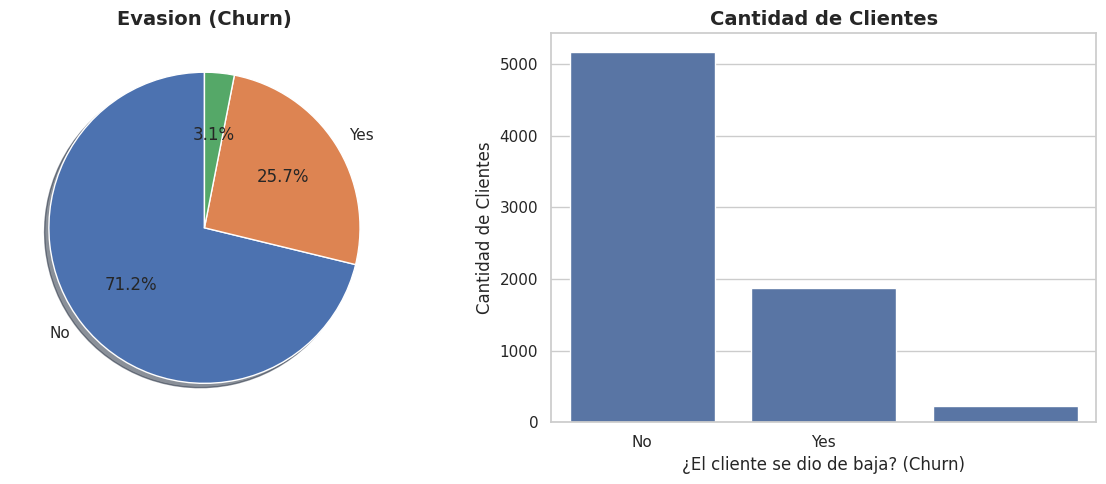

In [45]:
#Me estuvo dando problemas para graficar, porque la columna CHURN tenia un valor que no habia visto.
datos_churn = df_normalizado['Churn'].value_counts()
print("valores de la columna Churn:")
print(datos_churn)
print("-" * 50)

#lienzo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Grafico de Torta
axes[0].pie(
    x=datos_churn.values,
    labels=datos_churn.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)
axes[0].set_title('Evasion (Churn)', fontsize=14, fontweight='bold')

#Grafico de barras
sns.countplot(
    data=df_normalizado,
    x='Churn',
    ax=axes[1]
)
axes[1].set_title('Cantidad de Clientes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('¿El cliente se dio de baja? (Churn)', fontsize=12)
axes[1].set_ylabel('Cantidad de Clientes', fontsize=12)

# Mostramos
plt.tight_layout()
plt.show()

#####En cantidad de clientes tuvimos datos sucios, por lo cual a la hs de graficar me genero unos cuantos problemas, y como vemos ahi, se tratan de datos nulos o espacios en blanco.

####Recuento de evasión por variables categóricas

/tmp/ipykernel_316/687817780.py:6: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df_normalizado, x='gender', hue='Churn', palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_316/687817780.py:13: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df_normalizado, x='Contract', hue='Churn', palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_316/687817780.py:20: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df_normalizado, x='PaymentMethod', hue='Churn', palette=['#4C72B0', '#C44E52'])


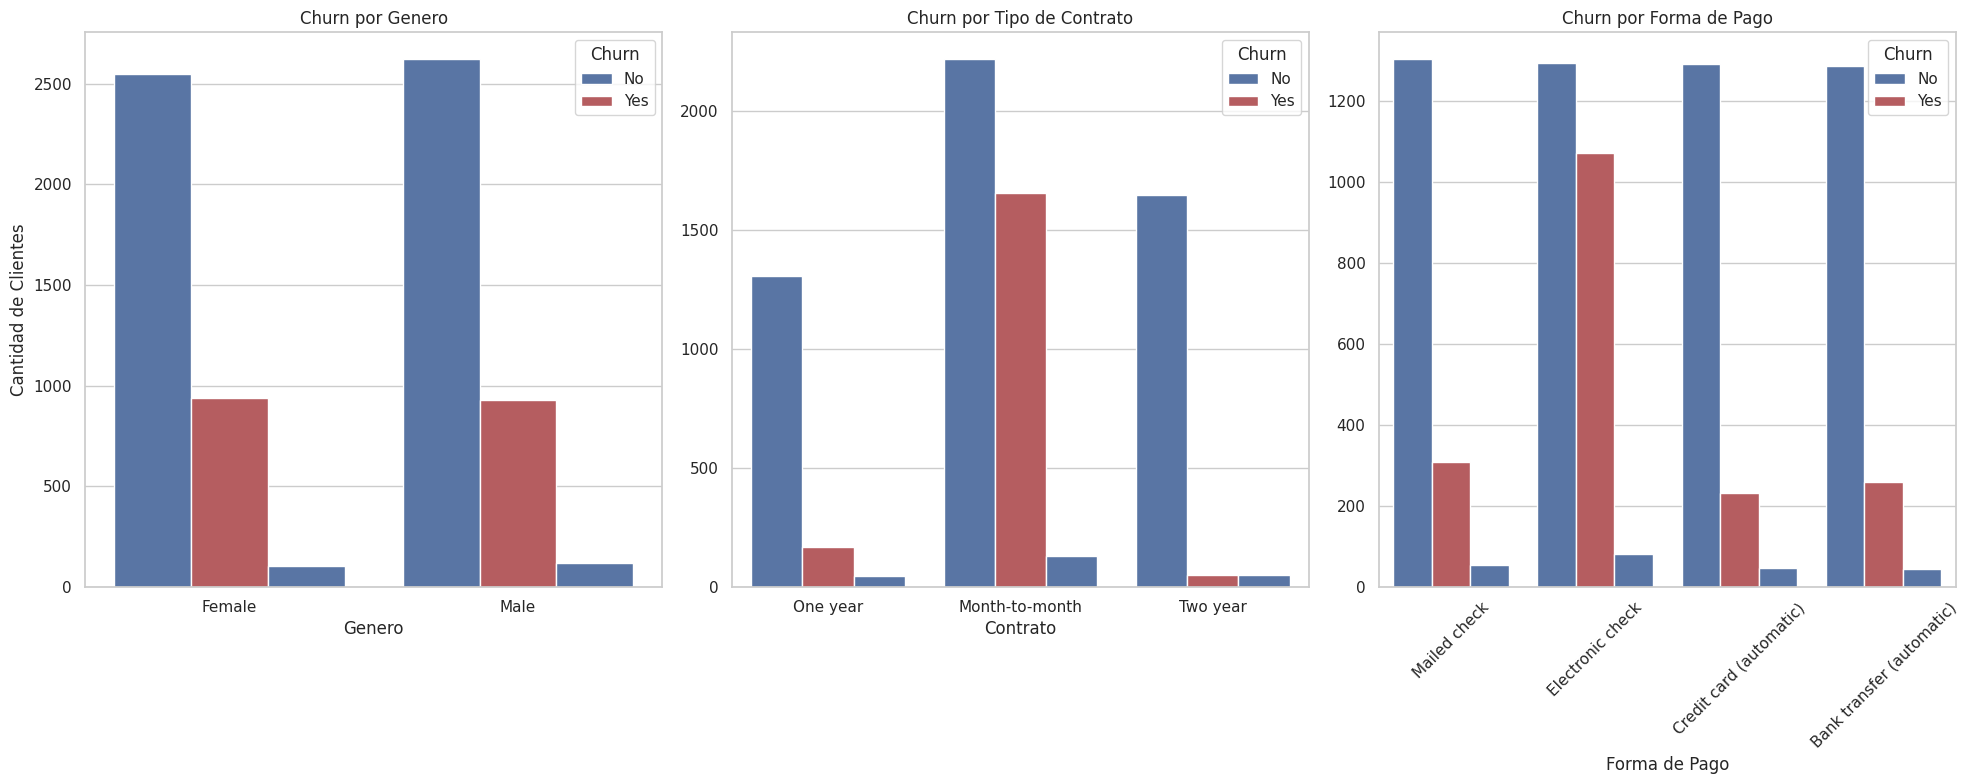

In [48]:
# Configuramos el tamaño de la figura para que entren los 3 gráficos
plt.figure(figsize=(20, 8))

#Grafico de genero
plt.subplot(1, 3, 1) # (1 fila, 3 columnas, posicion 1)
sns.countplot(data=df_normalizado, x='gender', hue='Churn', palette=['#4C72B0', '#C44E52'])
plt.title('Churn por Genero')
plt.xlabel('Genero')
plt.ylabel('Cantidad de Clientes')

#Grafico de Contrato
plt.subplot(1, 3, 2) # (1 fila, 3 columnas, posición 2)
sns.countplot(data=df_normalizado, x='Contract', hue='Churn', palette=['#4C72B0', '#C44E52'])
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Contrato')
plt.ylabel('') # Ocultamos para que no se amontone

#Grafico de Pago
plt.subplot(1, 3, 3) #(1 fila, 3 columnas, posicion 3)
sns.countplot(data=df_normalizado, x='PaymentMethod', hue='Churn', palette=['#4C72B0', '#C44E52'])
plt.title('Churn por Forma de Pago')
plt.xlabel('Forma de Pago')
plt.xticks(rotation=45) #giramos 45° los nombres
plt.ylabel('')

#Ajustamos las etiquetas
plt.tight_layout()
plt.show()

####Analisis de evasion por variables numericas

/tmp/ipykernel_316/4231954502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_normalizado, x='Churn', y='tenure', palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_316/4231954502.py:6: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df_normalizado, x='Churn', y='tenure', palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_316/4231954502.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_normalizado, x='Churn', y='Charges.Monthly', palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_316/4231954502.py:13: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle

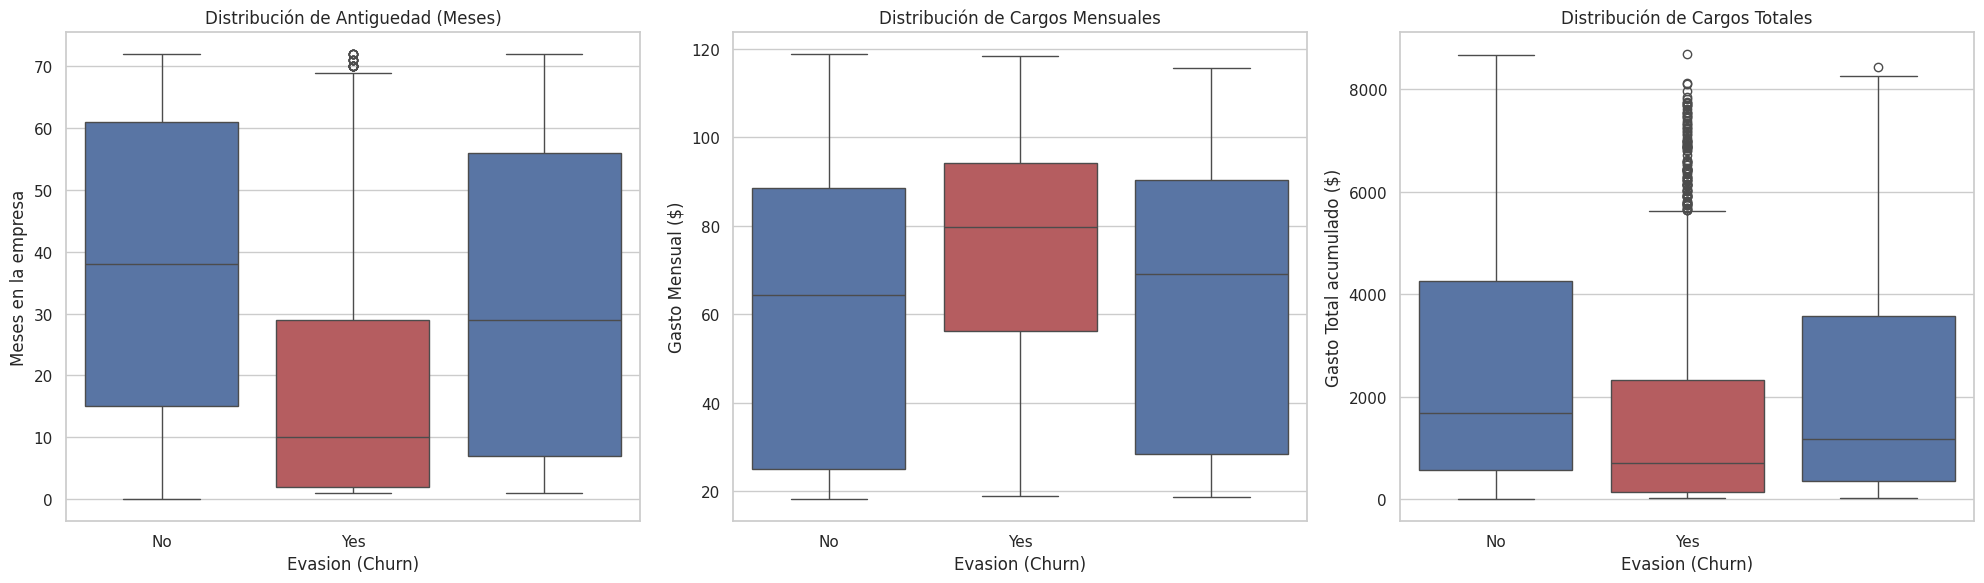


--- Promedio de valores segun la Evasion (Churn) ---


,tenure,Charges.Monthly,Charges.Total
Churn,,,
,31.571429,63.412277,2196.933705
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


In [49]:
#Lienzo de 3 graficos
plt.figure(figsize=(20, 6))

#Grafico de antiguedad
plt.subplot(1, 3, 1)
sns.boxplot(data=df_normalizado, x='Churn', y='tenure', palette=['#4C72B0', '#C44E52'])
plt.title('Distribución de Antiguedad (Meses)')
plt.xlabel('Evasion (Churn)')
plt.ylabel('Meses en la empresa')

#Grafico de cargos mensuales
plt.subplot(1, 3, 2)
sns.boxplot(data=df_normalizado, x='Churn', y='Charges.Monthly', palette=['#4C72B0', '#C44E52'])
plt.title('Distribución de Cargos Mensuales')
plt.xlabel('Evasion (Churn)')
plt.ylabel('Gasto Mensual ($)')

#Grafico de Cargos Totales
plt.subplot(1, 3, 3)
sns.boxplot(data=df_normalizado, x='Churn', y='Charges.Total', palette=['#4C72B0', '#C44E52'])
plt.title('Distribución de Cargos Totales')
plt.xlabel('Evasion (Churn)')
plt.ylabel('Gasto Total acumulado ($)')

plt.tight_layout()
plt.show()

#Tabla de Promedios (Insights)
print("\n--- Promedio de valores segun la Evasion (Churn) ---")
resumen_numerico = df_normalizado.groupby('Churn')[['tenure', 'Charges.Monthly', 'Charges.Total']].mean()
display(resumen_numerico)

##📊 Informe Final de Análisis: Evasión de Clientes (Telecom X)
###🔹 1. Introducción
El objetivo de este proyecto fue analizar el comportamiento de los clientes de Telecom X para identificar los factores que impulsan la evasión (Churn). El Churn es uno de los desafíos más críticos para las empresas de telecomunicaciones, ya que retener a un cliente existente es más económico que adquirir uno nuevo. A traves de este analisis, transformamos datos crudos en estrategias para reducir la pérdida de usuarios.

###🔹 2. Limpieza y Tratamiento de Datos
Para asegurar la integridad del analisis, realizamos un proceso de ETL (Extracción, Transformación y Carga) detallado:

**Normalización:** Los datos originales en formato JSON fueron normalizados para obtener una estructura tabular clara de 21 columnas.

**Corrección de Formatos:** Identificamos que la columna **Charges.Total** estaba en formato de texto. Se forzó su conversión a tipo numérico, lo que reveló 11 valores nulos correspondientes a clientes nuevos (0 meses de antigüedad).

**Tratamiento de Nulos y Duplicados:** Se rellenaron los valores nulos con 0 (ya que no habían generado cargos aún) y se eliminaron filas duplicadas para evitar sesgos.

**Ingeniería de Datos:** Creamos la métrica **Cuentas_Diarias** dividiendo el cargo mensual por 30, permitiendo una visión más granular del gasto por cliente.

###🔹 3. Análisis Exploratorio de Datos (EDA)
Mediante visualizaciones estratégicas, identificamos patrones clave en la distribución de la evasión:

**Tasa de Churn:** Aproximadamente el 26.5% de la base de clientes ha abandonado el servicio, lo que representa una alerta roja para la estabilidad financiera.

**Contratos:** Los clientes con contratos mes a mes (Month-to-month) muestran la tasa de fuga más alta, mientras que los contratos a uno o dos años generan una lealtad significativamente mayor.

**Antigüedad:** Existe una correlación negativa entre el tiempo de permanencia y el Churn. Los clientes son más propensos a irse en sus primeros 6 a 12 meses.

**Métodos de Pago:** El uso de Cheque Electrónico (Electronic Check) esta fuertemente asociado con una mayor tasa de abandono en comparación con los pagos automaticos.

###🔹 4. Conclusiones e Insights
**El "Período Crítico":** La mayoría de las fugas ocurren al inicio de la relacion comercial. Si un cliente supera el primer año, la probabilidad de que se quede aumenta drasticamente.

**Barreras de Salida:** Los contratos a largo plazo funcionan como una excelente barrera de retención, pero la empresa tiene una gran masa de clientes en esquemas volatiles (mes a mes).

**Costo del Servicio:** Los clientes que cancelan tienden a tener cargos mensuales promedio mas altos, lo que sugiere que podrían estar migrando a competidores con mejores ofertas de precio o valor percibido.

###🔹 5. Recomendaciones Estratégicas
Basandonos en los datos, sugerimos las siguientes acciones:

**Plan de Confiabilidad:** Implementar descuentos o beneficios exclusivos para clientes en sus primeros 6 meses de servicio.

**Incentivos a la Permanencia:** Ofrecer bonificaciones en servicios adicionales (como más datos o streaming gratuito) a cambio de migrar de un contrato mensual a uno anual.

**Facilidad de Pagos:** Promocionar el uso de pagos automáticos (tarjeta de crédito/banco) mediante pequeños descuentos fijos, reduciendo la fricción y el Churn asociado al cheque electrónico.

**Feedback de Salida:** Dado que el Churn es alto en facturas elevadas, realizar llamadas preventivas a clientes con cargos altos para ofrecer planes de retención personalizados.